# Lista 5: Połączenia residualne / Transfer learning

In [1]:
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torchvision.models as models
import copy
import time
import matplotlib.pyplot as plt

## Zadanie 1: Implementacja modelu residualnego

In [2]:
#Dummy wejście (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

# Ustalmy powtarzalność
torch.manual_seed(0)

# Dummy batch obrazów: (batch_size, channels, height, width)
B, C, H, W = 4, 16, 32, 32
x = torch.randn(B, C, H, W)
print("x shape:", x.shape)

x shape: torch.Size([4, 16, 32, 32])


In [3]:
# Moduł ResidualBlock z brakującym kodem

class ResidualBlock(nn.Module):
    """
    Blok residualny zgodny ze schematem:
        x -> Conv -> ReLU -> Conv -> ( + x ) -> ReLU
    Zakładamy, że wejście i wyjście mają te same wymiary (C, H, W).
    """
    def __init__(self, channels: int, kernel_size: int = 3):
        super().__init__()
        padding = kernel_size // 2  # żeby zachować H,W dla kernel=3

        self.conv1 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=kernel_size, padding=padding, bias=True)
        self.relu = nn.ReLU(inplace=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # w fx przechodzimy normalnie, dodajemy do niego zwykłe x i wrzucamy do relu
        fx = self.conv1(x)
        fx = self.relu(fx)
        fx = self.conv2(fx)
        out = fx + x
        out = self.relu(out)
        return out


In [4]:
# Testy (NIE NALEŻY MODYFIKOWAĆ KOMÓRKI)

def zero_out_conv(conv: nn.Conv2d):
    with torch.no_grad():
        conv.weight.zero_()
        if conv.bias is not None:
            conv.bias.zero_()

# 1) Inicjalizacja i test wymiarów
block = ResidualBlock(channels=C)

y = block(x)
print("y shape:", y.shape)

assert y.shape == x.shape, f"Shape mismatch: got {y.shape}, expected {x.shape}"
print("Shape test passed")

# 2) Test semantyczny: jeśli ustawimy wagi obu conv na 0 -> F(x)=0
#    wtedy y = ReLU(x) (bo na końcu jest ReLU po dodaniu).
zero_out_conv(block.conv1)
zero_out_conv(block.conv2)

y2 = block(x)
expected = torch.relu(x)

max_diff = (y2 - expected).abs().max().item()
print("max |y2 - ReLU(x)| =", max_diff)

assert torch.allclose(y2, expected, atol=1e-6), "Residual behavior test failed"
print("Residual behavior test passed (F(x)=0 => y=ReLU(x))")

# 3) Test gradientu: sprawdzamy czy gradient przepływa do x
x_req = x.clone().detach().requires_grad_(True)
y3 = block(x_req)
loss = y3.sum()
loss.backward()

grad_norm = x_req.grad.norm().item()
print("x grad norm:", grad_norm)

assert grad_norm > 0, "Gradient flow test failed (grad_norm should be > 0)"
print("Gradient flow test passed")

y shape: torch.Size([4, 16, 32, 32])
Shape test passed
max |y2 - ReLU(x)| = 0.0
Residual behavior test passed (F(x)=0 => y=ReLU(x))
x grad norm: 180.78993225097656
Gradient flow test passed


Działa

## Zadanie 2: Transfer learning

### 1. Wybór i analiza architektury
użyjemy resnet18 i ustawiamy wagi na te nauczone na imagenet

In [5]:
default_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


In [6]:
print(default_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Część konwolucyjna:
    Początek architektury zaczynamy od konwolucji na dużym filtrze 7x7 i stride = 2 -> bn1 -> relu -> maxpool. Sprawia to, że obraz od samego początku ma zmniejszoną rozdzielczość, którą podajemy nastepnym warstwom. Następnie na przestrzeni 4 warstw zwiększamy liczbę kanałów z 64 do 512, wykonująć konwolucje z filtrem 3x3

Ostatnia warstwa klasyfikacyjna:
    Przyjmuje od poprzednich warstw wektor o rozmiarze 512 i mapuje go na 1000 klas

Bloki residualne:
    Wykorzystujemy tutaj basicblock, który wykonuje: conv1 -> bn1 -> relu -> conv2 -> bn2
    dodatkowo wykonywany jest downsampling (konwolucja z filtrem 1x1 i stride 2 + bn) aby zgadzała się liczba kanałów




## 2. Wprowadzenie zbioru CIFAR

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# dopasowujemy zdjęcia do tego, na czym był pretrenowany nasz model
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Wczytanie zbioru CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = random_split(trainset, [train_size, val_size])

# DataLoadery
batch_size = 32
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

# Zastąpienie ostatniej warstwy liniowej, zamiast 1000 klas na wyjściu, chcemy mieć 10
num_classes_cifar = 10
num_features = default_model.fc.in_features
default_model.fc = torch.nn.Linear(num_features, num_classes_cifar)

100%|██████████| 170M/170M [00:08<00:00, 19.8MB/s]


Zanim przejdziemy do eksperymentów wprowadźmy przydatne funkcje

In [9]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def train_model(model, trainloader, valloader, criterion, optimizer, num_epochs, device):

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()

        # Trening
        train_loss, train_acc = train_epoch(model, trainloader, criterion, optimizer, device)

        # Walidacja
        val_loss, val_acc = evaluate(model, valloader, criterion, device)

        # Zapisz historię
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        epoch_time = time.time() - epoch_start

        print(f"Epoka [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
              f"Czas: {epoch_time:.2f}s")

    total_time = time.time() - start_time
    print(f"\nCałkowity czas treningu: {total_time:.2f}s")

    return history


def freeze_all_layers(model):
    for param in model.parameters():
        param.requires_grad = False


def unfreeze_all_layers(model):
    for param in model.parameters():
        param.requires_grad = True

# Eksperyment 1: Linear probbing

In [10]:
# Załaduj pretrenowany model
model1 = copy.deepcopy(default_model)

# Zamrażamy wszystkie warstwy
freeze_all_layers(model1)

# Odmrażamy ostatnią warstwę
for param in model1.fc.parameters():
    param.requires_grad = True

model1 = model1.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model1.fc.parameters(), lr=0.001)
num_epochs = 10

# Trening
history1 = train_model(model1, trainloader, valloader, criterion, optimizer,
                        num_epochs, device)

# Ewaluacja na zbiorze testowym
test_loss1, test_acc1 = evaluate(model1, testloader, criterion, device)
print(f"\nWynik testowy: Loss: {test_loss1:.4f} | Accuracy: {test_acc1:.2f}%")

Epoka [1/10] | Train Loss: 0.8368 | Train Acc: 72.27% | Val Loss: 0.6245 | Val Acc: 79.02% | Czas: 95.17s
Epoka [2/10] | Train Loss: 0.6500 | Train Acc: 77.66% | Val Loss: 0.5680 | Val Acc: 80.73% | Czas: 94.87s
Epoka [3/10] | Train Loss: 0.6269 | Train Acc: 78.58% | Val Loss: 0.5574 | Val Acc: 80.78% | Czas: 92.13s
Epoka [4/10] | Train Loss: 0.6132 | Train Acc: 78.86% | Val Loss: 0.5560 | Val Acc: 80.85% | Czas: 91.76s
Epoka [5/10] | Train Loss: 0.6054 | Train Acc: 79.05% | Val Loss: 0.5502 | Val Acc: 81.09% | Czas: 93.41s
Epoka [6/10] | Train Loss: 0.5979 | Train Acc: 79.27% | Val Loss: 0.5619 | Val Acc: 80.76% | Czas: 91.78s
Epoka [7/10] | Train Loss: 0.5996 | Train Acc: 79.14% | Val Loss: 0.5360 | Val Acc: 81.54% | Czas: 91.33s
Epoka [8/10] | Train Loss: 0.5912 | Train Acc: 79.53% | Val Loss: 0.5459 | Val Acc: 80.69% | Czas: 90.77s
Epoka [9/10] | Train Loss: 0.5875 | Train Acc: 79.94% | Val Loss: 0.5417 | Val Acc: 80.95% | Czas: 93.50s
Epoka [10/10] | Train Loss: 0.5856 | Train Acc

# Eksperyment 2: Partial fine-tuning

In [11]:
model2 = copy.deepcopy(default_model)

# Zamroź wszystkie warstwy
freeze_all_layers(model2)

# Odmroź ostatni blok ResNeta (layer4)
for param in model2.layer4.parameters():
    param.requires_grad = True

for param in model2.fc.parameters():
    param.requires_grad = True


model2 = model2.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model2.parameters()), lr=0.0005)
num_epochs = 10

history2 = train_model(model2, trainloader, valloader, criterion, optimizer,
                        num_epochs, device)

test_loss2, test_acc2 = evaluate(model2, testloader, criterion, device)
print(f"\nWynik testowy: Loss: {test_loss2:.4f} | Accuracy: {test_acc2:.2f}%")

Epoka [1/10] | Train Loss: 0.4741 | Train Acc: 83.82% | Val Loss: 0.3381 | Val Acc: 87.99% | Czas: 97.47s
Epoka [2/10] | Train Loss: 0.2234 | Train Acc: 92.44% | Val Loss: 0.3095 | Val Acc: 89.70% | Czas: 97.81s
Epoka [3/10] | Train Loss: 0.1286 | Train Acc: 95.53% | Val Loss: 0.3445 | Val Acc: 89.26% | Czas: 97.10s
Epoka [4/10] | Train Loss: 0.0835 | Train Acc: 97.11% | Val Loss: 0.3609 | Val Acc: 89.39% | Czas: 98.57s
Epoka [5/10] | Train Loss: 0.0641 | Train Acc: 97.69% | Val Loss: 0.3713 | Val Acc: 90.20% | Czas: 98.23s
Epoka [6/10] | Train Loss: 0.0546 | Train Acc: 98.20% | Val Loss: 0.3679 | Val Acc: 90.49% | Czas: 98.54s
Epoka [7/10] | Train Loss: 0.0478 | Train Acc: 98.41% | Val Loss: 0.4155 | Val Acc: 89.74% | Czas: 98.16s
Epoka [8/10] | Train Loss: 0.0415 | Train Acc: 98.59% | Val Loss: 0.4391 | Val Acc: 89.60% | Czas: 98.97s
Epoka [9/10] | Train Loss: 0.0308 | Train Acc: 98.99% | Val Loss: 0.4309 | Val Acc: 90.20% | Czas: 99.21s
Epoka [10/10] | Train Loss: 0.0358 | Train Acc

## Eksperyment 3: Full Fine-tuning

In [12]:
model3 = copy.deepcopy(default_model)

# Wszystkie warstwy są domyślnie odmrożone
model3 = model3.to(device)

# Ustawienia treningu
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=0.0001)
num_epochs = 10

history3 = train_model(model3, trainloader, valloader, criterion, optimizer,
                        num_epochs, device)

test_loss3, test_acc3 = evaluate(model3, testloader, criterion, device)
print(f"\nWynik testowy: Loss: {test_loss3:.4f} | Accuracy: {test_acc3:.2f}%")

Epoka [1/10] | Train Loss: 0.3597 | Train Acc: 88.17% | Val Loss: 0.2152 | Val Acc: 93.17% | Czas: 163.97s
Epoka [2/10] | Train Loss: 0.1355 | Train Acc: 95.60% | Val Loss: 0.1716 | Val Acc: 94.07% | Czas: 163.96s
Epoka [3/10] | Train Loss: 0.0693 | Train Acc: 97.79% | Val Loss: 0.2072 | Val Acc: 93.47% | Czas: 163.73s
Epoka [4/10] | Train Loss: 0.0549 | Train Acc: 98.23% | Val Loss: 0.2771 | Val Acc: 91.87% | Czas: 164.50s
Epoka [5/10] | Train Loss: 0.0458 | Train Acc: 98.44% | Val Loss: 0.2088 | Val Acc: 93.86% | Czas: 164.13s
Epoka [6/10] | Train Loss: 0.0376 | Train Acc: 98.76% | Val Loss: 0.2116 | Val Acc: 93.89% | Czas: 164.76s
Epoka [7/10] | Train Loss: 0.0362 | Train Acc: 98.81% | Val Loss: 0.2349 | Val Acc: 93.37% | Czas: 163.84s
Epoka [8/10] | Train Loss: 0.0296 | Train Acc: 99.09% | Val Loss: 0.2205 | Val Acc: 93.95% | Czas: 164.29s
Epoka [9/10] | Train Loss: 0.0282 | Train Acc: 99.04% | Val Loss: 0.2073 | Val Acc: 94.06% | Czas: 164.16s
Epoka [10/10] | Train Loss: 0.0261 | 

## Eksperyment 4: Trening od zera

In [16]:
model4 = models.resnet18(weights=None)
model4.fc = nn.Linear(model4.fc.in_features, 10)
model4 = model4.to(device)

# Ustawienia treningu
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model4.parameters(), lr=0.001)
num_epochs = 15

# Trening
history4 = train_model(model4, trainloader, valloader, criterion, optimizer,
                        num_epochs, device)

# Ewaluacja na zbiorze testowym
test_loss4, test_acc4 = evaluate(model4, testloader, criterion, device)
print(f"\nWynik testowy: Loss: {test_loss4:.4f} | Accuracy: {test_acc4:.2f}%")

Epoka [1/15] | Train Loss: 1.4323 | Train Acc: 47.58% | Val Loss: 1.0821 | Val Acc: 60.41% | Czas: 163.85s
Epoka [2/15] | Train Loss: 0.8881 | Train Acc: 68.67% | Val Loss: 0.7398 | Val Acc: 74.08% | Czas: 165.77s
Epoka [3/15] | Train Loss: 0.6739 | Train Acc: 76.80% | Val Loss: 0.7564 | Val Acc: 74.22% | Czas: 166.15s
Epoka [4/15] | Train Loss: 0.5427 | Train Acc: 81.11% | Val Loss: 0.7814 | Val Acc: 73.86% | Czas: 165.86s
Epoka [5/15] | Train Loss: 0.4330 | Train Acc: 85.17% | Val Loss: 0.6039 | Val Acc: 80.31% | Czas: 165.03s
Epoka [6/15] | Train Loss: 0.3344 | Train Acc: 88.37% | Val Loss: 0.5810 | Val Acc: 81.33% | Czas: 165.00s
Epoka [7/15] | Train Loss: 0.2438 | Train Acc: 91.44% | Val Loss: 0.5641 | Val Acc: 82.45% | Czas: 164.77s
Epoka [8/15] | Train Loss: 0.1750 | Train Acc: 93.80% | Val Loss: 0.6026 | Val Acc: 83.05% | Czas: 165.45s
Epoka [9/15] | Train Loss: 0.1245 | Train Acc: 95.71% | Val Loss: 0.6885 | Val Acc: 81.85% | Czas: 165.73s
Epoka [10/15] | Train Loss: 0.1039 | 

Zobaczmy wyniki tych eksperymentów na wykresie

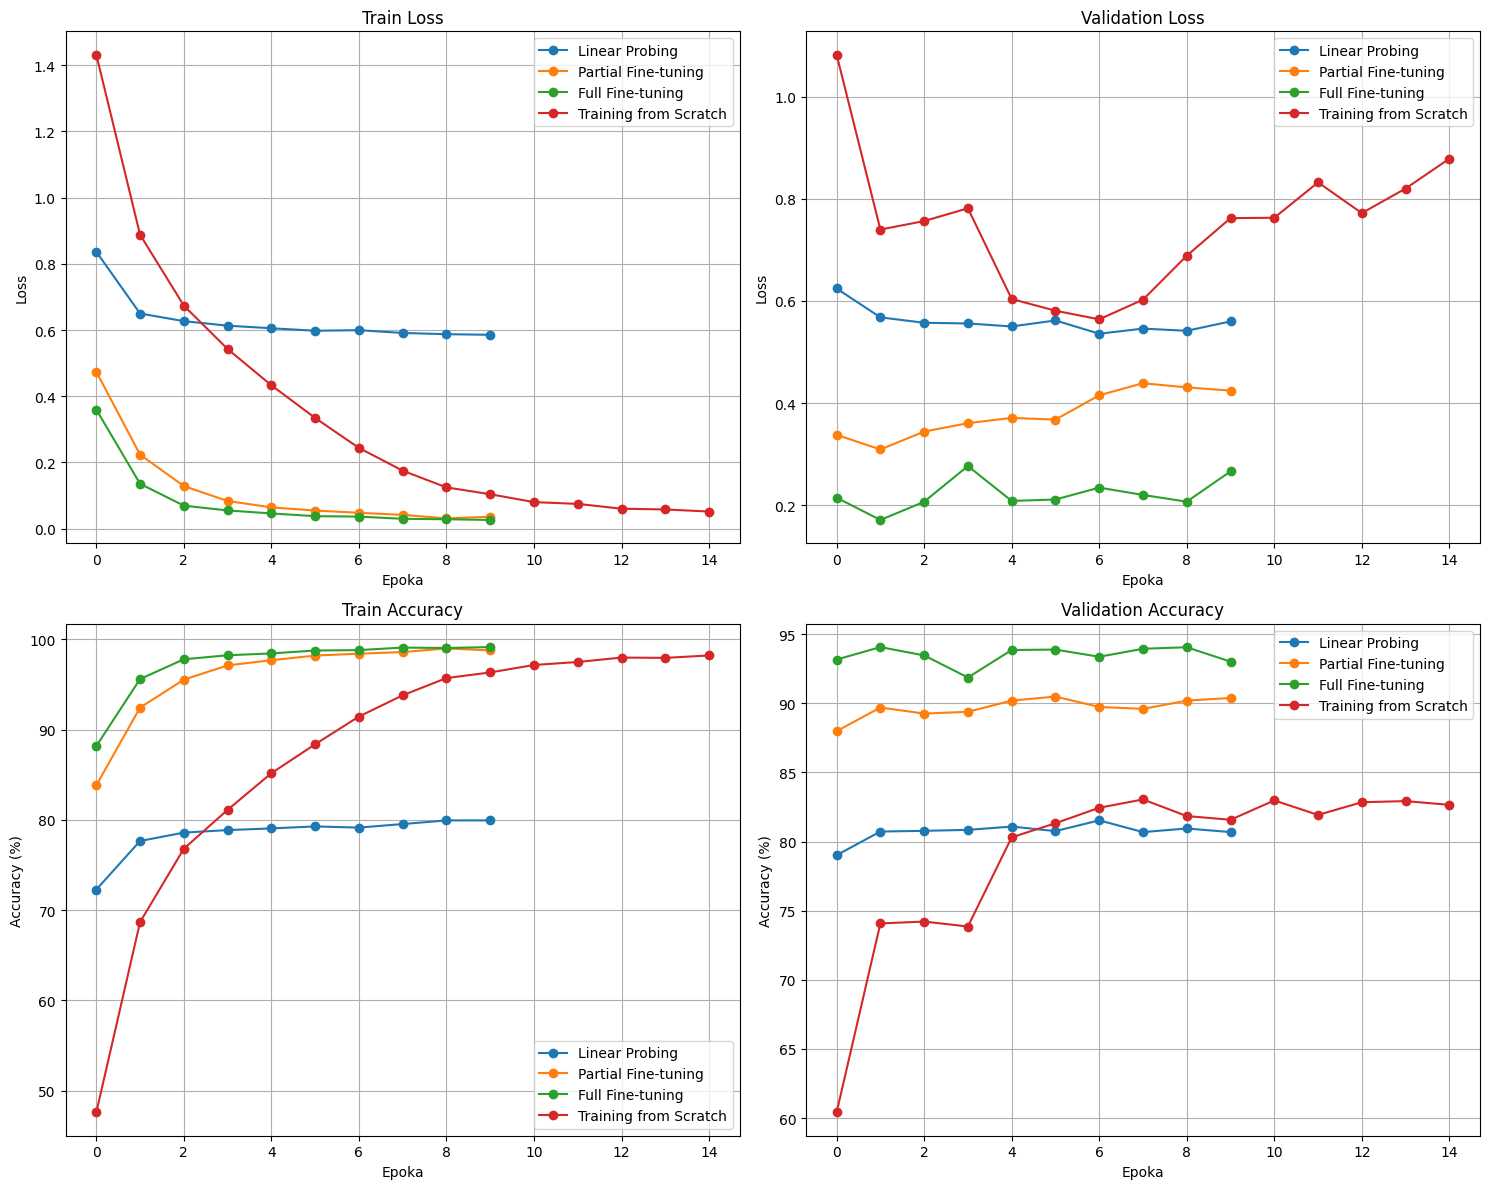

Linear Probing                : 79.90%
Partial Fine-tuning           : 90.32%
Full Fine-tuning              : 92.54%
Training from Scratch         : 82.58%


In [17]:
histories = [history1, history2, history3, history4]
names = ['Linear Probing', 'Partial Fine-tuning', 'Full Fine-tuning', 'Training from Scratch']
test_accuracies = [test_acc1, test_acc2, test_acc3, test_acc4]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Train Loss
ax = axes[0, 0]
for hist, name in zip(histories, names):
    ax.plot(hist['train_loss'], label=name, marker='o')
ax.set_xlabel('Epoka')
ax.set_ylabel('Loss')
ax.set_title('Train Loss')
ax.legend()
ax.grid(True)

# Validation Loss
ax = axes[0, 1]
for hist, name in zip(histories, names):
    ax.plot(hist['val_loss'], label=name, marker='o')
ax.set_xlabel('Epoka')
ax.set_ylabel('Loss')
ax.set_title('Validation Loss')
ax.legend()
ax.grid(True)

# Train Accuracy
ax = axes[1, 0]
for hist, name in zip(histories, names):
    ax.plot(hist['train_acc'], label=name, marker='o')
ax.set_xlabel('Epoka')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Train Accuracy')
ax.legend()
ax.grid(True)

# Validation Accuracy
ax = axes[1, 1]
for hist, name in zip(histories, names):
    ax.plot(hist['val_acc'], label=name, marker='o')
ax.set_xlabel('Epoka')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Validation Accuracy')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

for name, acc in zip(names, test_accuracies):
        print(f"{name:30s}: {acc:.2f}%")

## Wnioski:

Linear probing poradził sobie najgorzej, chociaż wciąż nieźle, dając wynik lepszy od losowego przy najszybszym treningu. Z racji że model jest nauczony na ogólnych kształtach a nie na konkretnych z cifar, to nie ma overfitu i accuracy na walidacji jest niemalże identyczna co na zbiorze testowym. I tak to idzie, że im więcej wag odmrozimy, tym rośnie ryzyko overfittingu, ale też poprawia się jakość modelu no i czas trenowania jest dłuższy. W przypadku trenowania od zera bez pretrenowanych wag, model na początku ma słabą jakość (no bo wagi są losowe) ale wraz z trwaniem uczenia, wynik jest coraz lepszy, przy czym występuje tutaj ponownie przetrenowanie i jakość na zbiorze testowym spada w porównaniu do jakości trenowania i walidacji. Generalnie pretrenowany model dobrze generalizuje i w zależności od liczby odmrożonych wag możemy balansować między jakością modelu a jego czasem trenowania co eksperymenty pokazują, gdzie widaż, że full fine-tuning i partial fine-tuning wychodzą najlepiej